# Model Evaluation

Evaluates all 5 trained models against the test set (post 2023-08-01).

Sections:
1. Setup
2. Load models and test set
3. Brier Score
4. Calibration Curves
5. Confusion Matrix + Classification Report
6. Backtesting over time + Per-season breakdown
7. Baseline comparison
8. Goals model investigation
9. New teams preparation (next season)

## 1. Setup

In [17]:
import subprocess, sys as _sys
subprocess.run(
    [_sys.executable, "-m", "pip", "install", "-r",
     str(__import__("pathlib").Path().resolve().parent.parent / "requirements.txt"), "-q"],
    check=False
)

CompletedProcess(args=['c:\\Users\\juliu\\OneDrive\\Desktop\\Projects\\Soca-Scores\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-r', 'C:\\Users\\juliu\\OneDrive\\Desktop\\Projects\\Soca-Scores\\requirements.txt', '-q'], returncode=0)

In [18]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    mean_absolute_error,
    classification_report,
)
from sklearn.calibration import calibration_curve

from src.components.features import FEATURE_COLS

MODELS_DIR = Path().resolve().parent.parent / 'models'
DATA_PATH  = Path().resolve().parent.parent / 'datasets' / 'processed' / 'feature_engineered_dataset.csv'
SPLIT_DATE = '2023-08-01'

print('Setup complete')

Setup complete


## 2. Load Models and Test Set

In [19]:
# Load models
model_result = XGBClassifier()
model_result.load_model(MODELS_DIR / 'soca_result.ubj')

model_btts = XGBClassifier()
model_btts.load_model(MODELS_DIR / 'soca_btts.ubj')

model_over25 = XGBClassifier()
model_over25.load_model(MODELS_DIR / 'soca_over25.ubj')

model_over15 = XGBClassifier()
model_over15.load_model(MODELS_DIR / 'soca_over15.ubj')

model_goals = XGBRegressor()
model_goals.load_model(MODELS_DIR / 'soca_goals.ubj')

print('All 5 models loaded')

All 5 models loaded


In [20]:
# Load and split dataset
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

test = df[df['Date'] >= SPLIT_DATE].copy()

X_test = test[FEATURE_COLS]

print(f'Test set: {len(test)} matches')
print(f'Date range: {test["Date"].min().date()} to {test["Date"].max().date()}')

Test set: 1064 matches
Date range: 2023-08-02 to 2026-12-04


In [5]:
# Generate all predictions
result_proba  = model_result.predict_proba(X_test)   # shape (n, 3): [away, draw, home]
result_pred   = model_result.predict(X_test)

btts_proba    = model_btts.predict_proba(X_test)[:, 1]
over25_proba  = model_over25.predict_proba(X_test)[:, 1]
over15_proba  = model_over15.predict_proba(X_test)[:, 1]
goals_pred    = model_goals.predict(X_test)

print('Predictions generated')

Predictions generated


## 3. Brier Score

Measures how well-calibrated the probability outputs are.
- 0.00 = perfect
- 0.25 = no skill (equivalent to always predicting 0.5)
- Below 0.20 = well calibrated for football prediction

In [6]:
# Result model — one Brier score per class
RESULT_LABELS = {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}

print('=== Result Model (per class) ===')
result_brier_scores = {}
for i, label in RESULT_LABELS.items():
    bs = brier_score_loss(
        (test['result_encoded'] == i).astype(int),
        result_proba[:, i]
    )
    result_brier_scores[label] = bs
    print(f'  {label:12s}: {bs:.4f}')

print(f'  Mean       : {np.mean(list(result_brier_scores.values())):.4f}')

print()
print('=== Binary Models ===')
binary_models = [
    ('BTTS',     btts_proba,   test['btts']),
    ('Over 2.5', over25_proba, test['over_2_5']),
    ('Over 1.5', over15_proba, test['over_1_5']),
]
for name, proba, actual in binary_models:
    bs = brier_score_loss(actual, proba)
    print(f'  {name:10s}: {bs:.4f}')

=== Result Model (per class) ===
  Away Win    : 0.2042
  Draw        : 0.1881
  Home Win    : 0.2273
  Mean       : 0.2066

=== Binary Models ===
  BTTS      : 0.2583
  Over 2.5  : 0.2591
  Over 1.5  : 0.1573


## 4. Calibration Curves

A perfectly calibrated model lies on the diagonal.
- Curve above diagonal = model is underconfident (predicts lower probabilities than it should)
- Curve below diagonal = model is overconfident

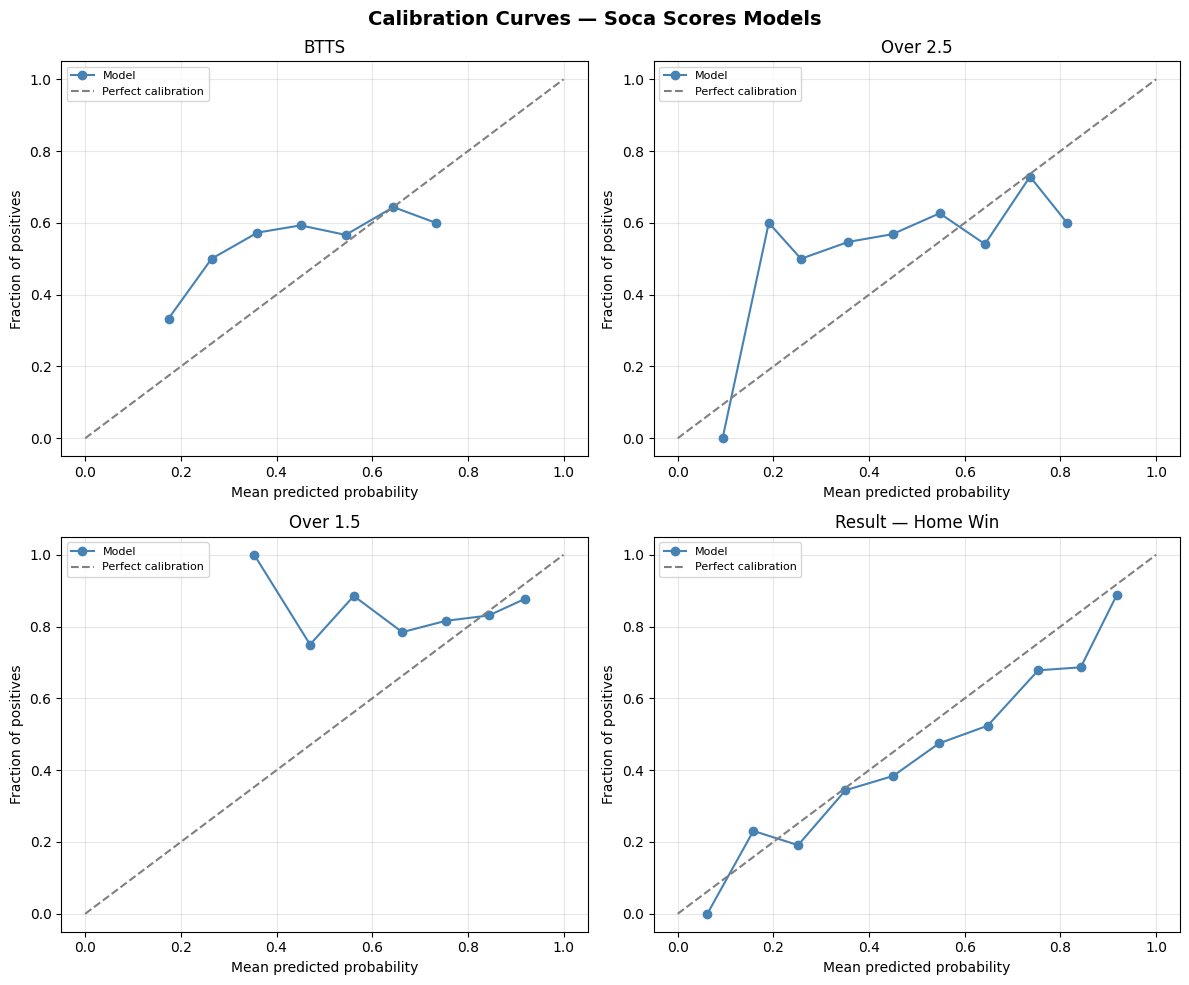

Saved: calibration_curves.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Calibration Curves — Soca Scores Models', fontsize=14, fontweight='bold')

calibration_targets = [
    ('BTTS',     btts_proba,   test['btts'],      axes[0, 0]),
    ('Over 2.5', over25_proba, test['over_2_5'],  axes[0, 1]),
    ('Over 1.5', over15_proba, test['over_1_5'],  axes[1, 0]),
    ('Result — Home Win', result_proba[:, 2],
     (test['result_encoded'] == 2).astype(int),   axes[1, 1]),
]

for name, proba, actual, ax in calibration_targets:
    fraction_pos, mean_pred = calibration_curve(actual, proba, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, fraction_pos, marker='o', label='Model', color='steelblue')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax.set_title(name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: calibration_curves.png')

## 5. Confusion Matrix — Result Model

Shows where the model confuses Home Win / Draw / Away Win.
The draw class is almost always the hardest to predict in football.

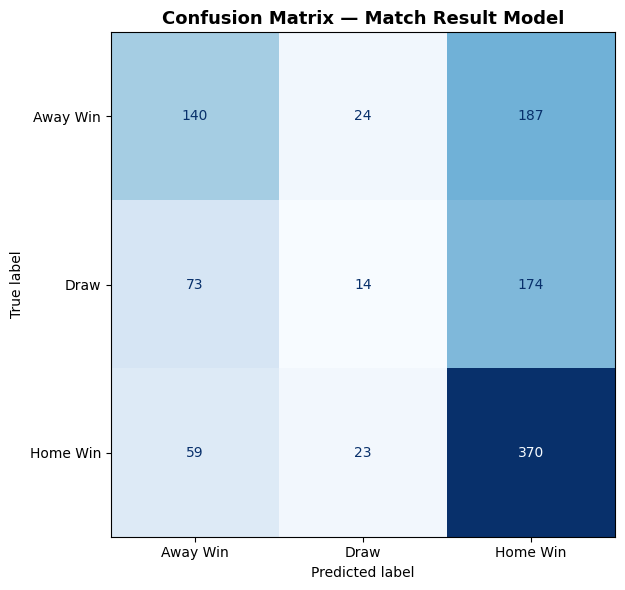

Actual class distribution in test set:
  Away Win    :  351 (33.0%)
  Draw        :  261 (24.5%)
  Home Win    :  452 (42.5%)


In [8]:
cm = confusion_matrix(test['result_encoded'], result_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Away Win', 'Draw', 'Home Win']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Match Result Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Class breakdown
print('Actual class distribution in test set:')
for i, label in RESULT_LABELS.items():
    count = (test['result_encoded'] == i).sum()
    pct   = count / len(test) * 100
    print(f'  {label:12s}: {count:4d} ({pct:.1f}%)')

### 5b. Classification Report — Per-class F1, Precision, Recall

The Draw class is the hardest to predict in football — this shows how each class performs individually.

              precision    recall  f1-score   support

    Away Win       0.51      0.40      0.45       351
        Draw       0.23      0.05      0.09       261
    Home Win       0.51      0.82      0.63       452

    accuracy                           0.49      1064
   macro avg       0.42      0.42      0.39      1064
weighted avg       0.44      0.49      0.44      1064



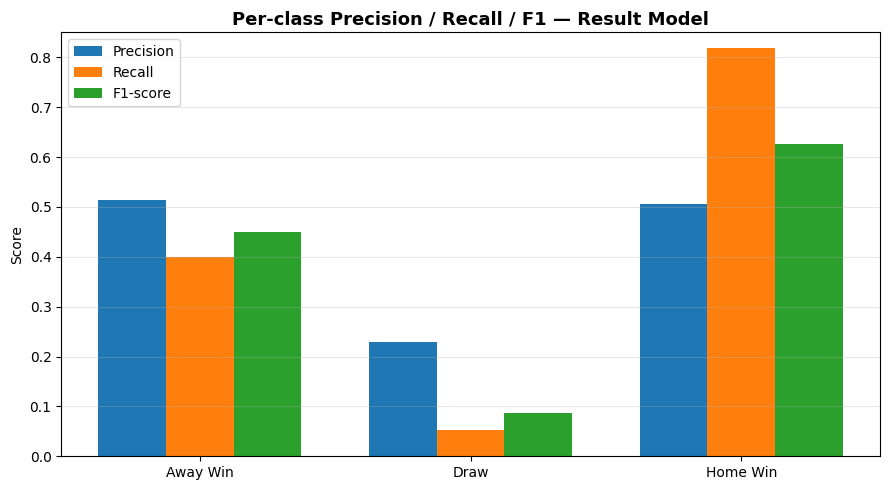

In [9]:
print(classification_report(
    test['result_encoded'],
    result_pred,
    target_names=['Away Win', 'Draw', 'Home Win']
))

# Visual F1 per class
report_dict = classification_report(
    test['result_encoded'], result_pred,
    target_names=['Away Win', 'Draw', 'Home Win'],
    output_dict=True
)
classes = ['Away Win', 'Draw', 'Home Win']
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, metric in enumerate(metrics):
    vals = [report_dict[c][metric] for c in classes]
    ax.bar(x + i * width, vals, width, label=metric.capitalize())

ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.set_title('Per-class Precision / Recall / F1 — Result Model', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('classification_report.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Backtesting Over Time

Tracks rolling accuracy across the test window.
Reveals whether the model degrades at certain points in the season or over time.

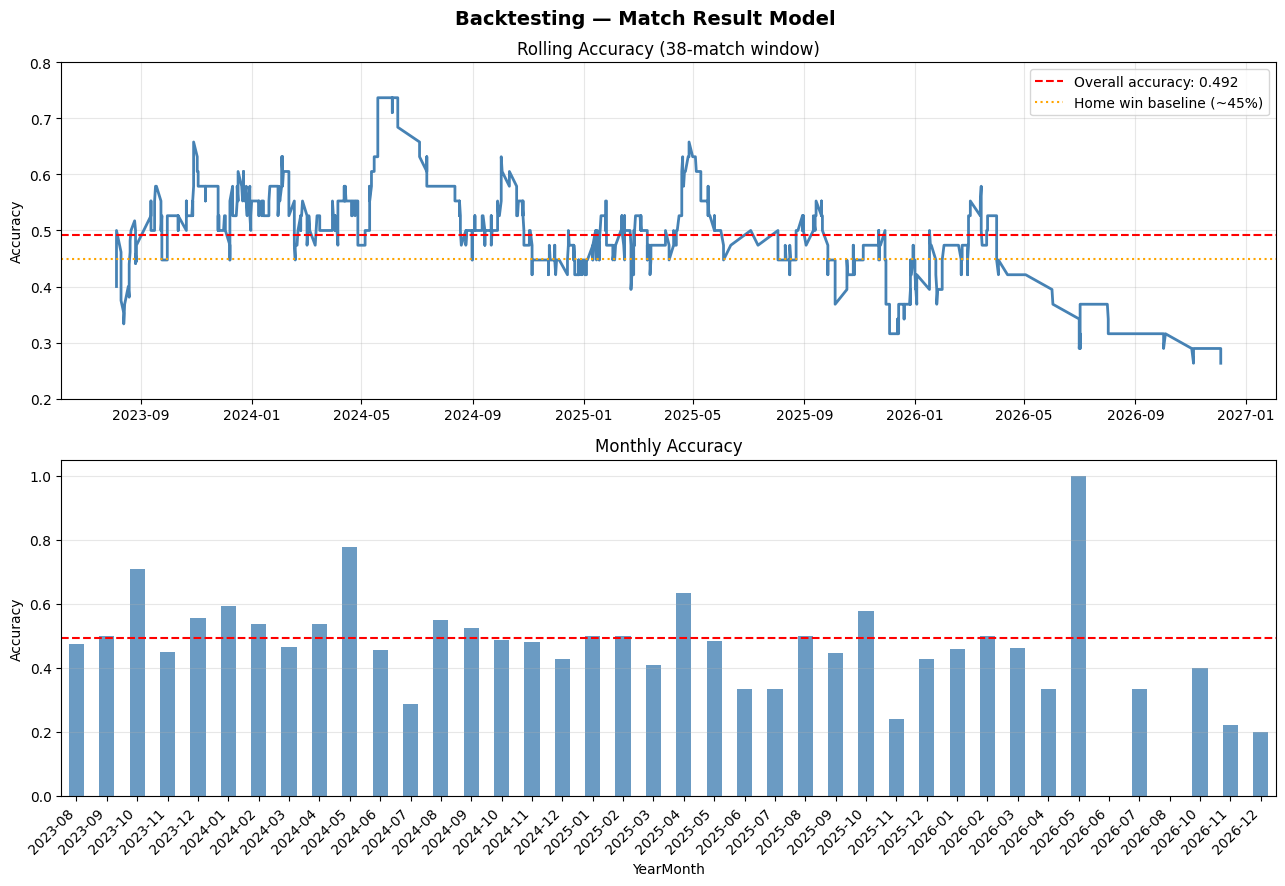

In [10]:
backtest = test[['Date', 'result_encoded']].copy()
backtest['predicted'] = result_pred
backtest['correct']   = (backtest['predicted'] == backtest['result_encoded']).astype(int)
backtest = backtest.sort_values('Date').reset_index(drop=True)

# Rolling accuracy (window = 38 matches ~ 1 season)
backtest['rolling_acc'] = backtest['correct'].rolling(window=38, min_periods=10).mean()

# Monthly accuracy
backtest['YearMonth'] = backtest['Date'].dt.to_period('M')
monthly_acc = backtest.groupby('YearMonth')['correct'].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('Backtesting — Match Result Model', fontsize=14, fontweight='bold')

# Rolling accuracy
ax1.plot(backtest['Date'], backtest['rolling_acc'], color='steelblue', linewidth=2)
ax1.axhline(y=backtest['correct'].mean(), color='red', linestyle='--',
            label=f'Overall accuracy: {backtest["correct"].mean():.3f}')
ax1.axhline(y=0.45, color='orange', linestyle=':', label='Home win baseline (~45%)')
ax1.set_title('Rolling Accuracy (38-match window)')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.2, 0.8)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Monthly accuracy
monthly_acc.plot(kind='bar', ax=ax2, color='steelblue', alpha=0.8)
ax2.axhline(y=backtest['correct'].mean(), color='red', linestyle='--')
ax2.set_title('Monthly Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_xticklabels([str(p) for p in monthly_acc.index], rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('backtesting.png', dpi=150, bbox_inches='tight')
plt.show()

### 6b. Per-Season Accuracy Breakdown

The test set spans three EPL seasons (2023/24, 2024/25, 2025/26).
Splitting by season reveals whether the model generalises across time or degrades on newer data.

=== Per-Season Accuracy ===
  2023/24  (376 matches)  █████████████████████  0.543
  2024/25  (382 matches)  ███████████████████  0.497
  2025/26  (284 matches)  █████████████████  0.440
  2026/27  ( 22 matches)  █████████  0.227


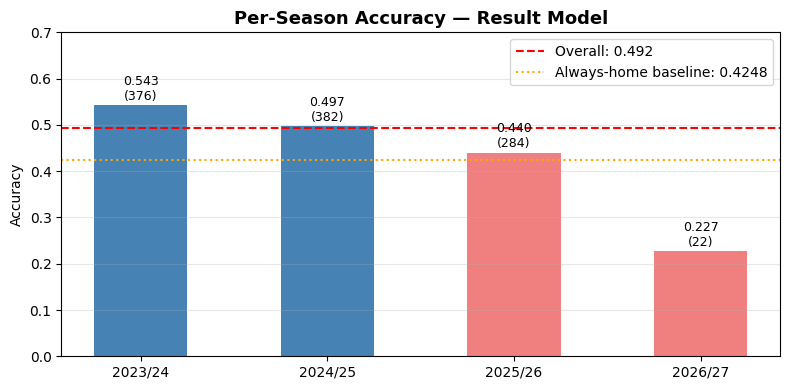

In [11]:
def get_season(date):
    if date.month >= 8:
        return f"{date.year}/{str(date.year + 1)[-2:]}"
    return f"{date.year - 1}/{str(date.year)[-2:]}"

season_df = test[['Date', 'result_encoded']].copy()
season_df['predicted'] = result_pred
season_df['correct']   = (season_df['predicted'] == season_df['result_encoded']).astype(int)
season_df['season']    = season_df['Date'].apply(get_season)

season_stats = season_df.groupby('season').agg(
    matches=('correct', 'count'),
    accuracy=('correct', 'mean')
).reset_index()

print('=== Per-Season Accuracy ===')
for _, row in season_stats.iterrows():
    bar = '█' * int(row['accuracy'] * 40)
    print(f"  {row['season']}  ({row['matches']:3d} matches)  {bar}  {row['accuracy']:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if acc > 0.45 else 'lightcoral'
          for acc in season_stats['accuracy']]
bars = ax.bar(season_stats['season'], season_stats['accuracy'], color=colors, width=0.5)
ax.axhline(y=season_df['correct'].mean(), color='red', linestyle='--',
           label=f'Overall: {season_df["correct"].mean():.3f}')
ax.axhline(y=0.4248, color='orange', linestyle=':', label='Always-home baseline: 0.4248')
ax.set_ylim(0, 0.7)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Season Accuracy — Result Model', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, (_, row) in zip(bars, season_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{row["accuracy"]:.3f}\n({row["matches"]})', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('per_season_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Baseline Comparison

The model must beat the simplest possible predictions to be useful.

- **Baseline 1**: Always predict Home Win (~45% of EPL matches are home wins)
- **Baseline 2**: Always predict the most common class in the training set
- **Baseline 3**: Random prediction weighted by class frequency

In [12]:
y_true = test['result_encoded'].values

# Baseline 1 — always predict Home Win (class 2)
baseline_home     = np.full(len(y_true), 2)
baseline_home_acc = accuracy_score(y_true, baseline_home)

# Baseline 2 — most common class in test set
most_common       = pd.Series(y_true).value_counts().idxmax()
baseline_common   = np.full(len(y_true), most_common)
baseline_common_acc = accuracy_score(y_true, baseline_common)

# Baseline 3 — weighted random
class_weights = pd.Series(y_true).value_counts(normalize=True).sort_index().values
np.random.seed(42)
baseline_random   = np.random.choice([0, 1, 2], size=len(y_true), p=class_weights)
baseline_random_acc = accuracy_score(y_true, baseline_random)

# Model accuracy
model_acc = accuracy_score(y_true, result_pred)

print('=== Result Model Baseline Comparison ===')
print(f'  Model accuracy         : {model_acc:.4f}')
print(f'  Baseline: always home  : {baseline_home_acc:.4f}')
print(f'  Baseline: most common  : {baseline_common_acc:.4f}')
print(f'  Baseline: weighted rand: {baseline_random_acc:.4f}')
print()
print(f'  Model beats always-home by: {(model_acc - baseline_home_acc)*100:+.2f}%')

# Goals baseline — predict the mean total goals
mean_goals_pred = np.full(len(test), test['total_goals'].mean())
baseline_goals_mae = mean_absolute_error(test['total_goals'], mean_goals_pred)
model_goals_mae    = mean_absolute_error(test['total_goals'], goals_pred)

print()
print('=== Goals Model Baseline Comparison ===')
print(f'  Model MAE              : {model_goals_mae:.4f}')
print(f'  Baseline: predict mean : {baseline_goals_mae:.4f}')
print(f'  Improvement over mean  : {baseline_goals_mae - model_goals_mae:.4f}')

=== Result Model Baseline Comparison ===
  Model accuracy         : 0.4925
  Baseline: always home  : 0.4248
  Baseline: most common  : 0.4248
  Baseline: weighted rand: 0.3543

  Model beats always-home by: +6.77%

=== Goals Model Baseline Comparison ===
  Model MAE              : 1.3358
  Baseline: predict mean : 1.2734
  Improvement over mean  : -0.0624


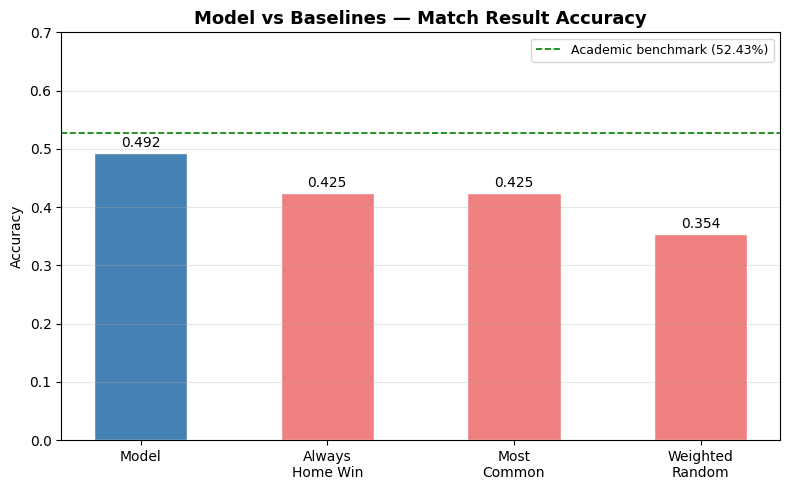

In [13]:
labels = ['Model', 'Always\nHome Win', 'Most\nCommon', 'Weighted\nRandom']
accs   = [model_acc, baseline_home_acc, baseline_common_acc, baseline_random_acc]
colors = ['steelblue', 'lightcoral', 'lightcoral', 'lightcoral']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='white', width=0.5)
ax.set_ylim(0, 0.7)
ax.set_ylabel('Accuracy')
ax.set_title('Model vs Baselines — Match Result Accuracy', fontsize=13, fontweight='bold')
ax.axhline(y=0.5267, color='green', linestyle='--', linewidth=1.2,
           label='Academic benchmark (52.43%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Goals Model Investigation

The goals model (MAE 1.3358) is **worse** than predicting the mean (MAE 1.2734).
This section investigates why — checking prediction distribution, feature importance, and whether the model has any signal at all.

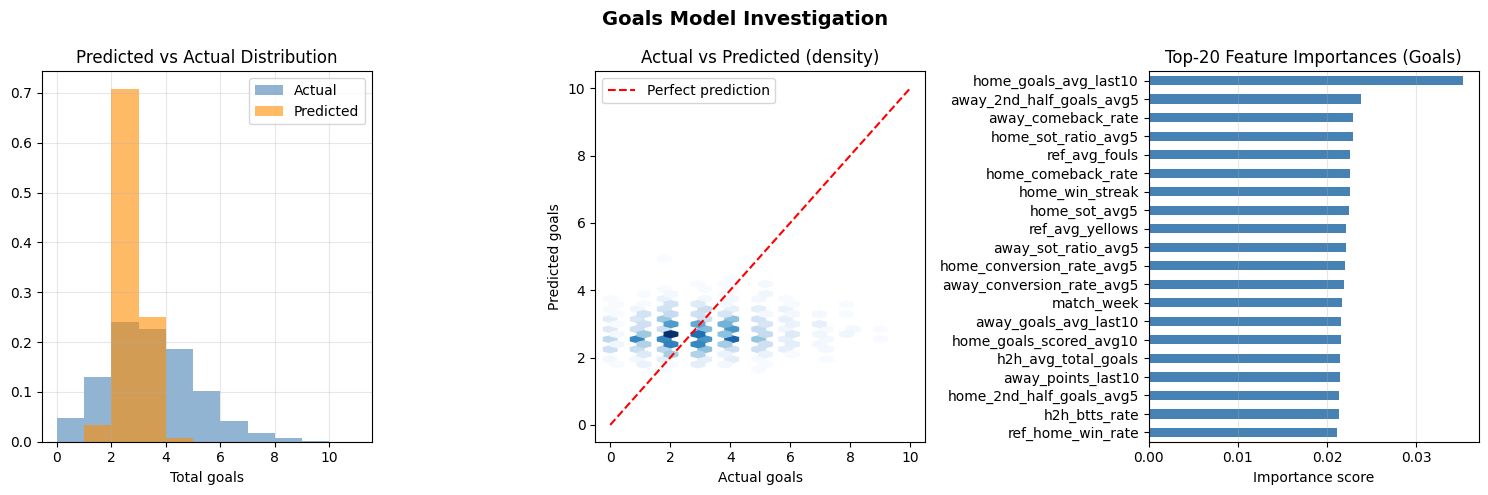

Actual goals   — mean: 2.983, std: 1.631, range: 0–9
Predicted goals — mean: 2.728, std: 0.443, range: 1.65–4.93
Pearson correlation (actual vs predicted): 0.0753

DIAGNOSIS: Model is mean-reverting — predictions cluster near the mean with low variance.
           This causes worse MAE than just predicting the mean for high/low goal matches.
           Root cause: goals are hard to predict; XGBoost is regularising toward mean.
           Fix options: (1) add shot-on-target features, (2) use Poisson regression,
                        (3) separate home/away goals models, (4) remove from app.


In [14]:
actual_goals = test['total_goals'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Goals Model Investigation', fontsize=14, fontweight='bold')

# 1. Predicted vs actual distribution
axes[0].hist(actual_goals, bins=range(0, 12), alpha=0.6, label='Actual', color='steelblue', density=True)
axes[0].hist(goals_pred,   bins=range(0, 12), alpha=0.6, label='Predicted', color='darkorange', density=True)
axes[0].set_title('Predicted vs Actual Distribution')
axes[0].set_xlabel('Total goals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Predicted vs actual scatter (hexbin for density)
axes[1].hexbin(actual_goals, goals_pred, gridsize=20, cmap='Blues', mincnt=1)
axes[1].plot([0, 10], [0, 10], 'r--', label='Perfect prediction')
axes[1].set_title('Actual vs Predicted (density)')
axes[1].set_xlabel('Actual goals')
axes[1].set_ylabel('Predicted goals')
axes[1].legend()

# 3. Top-20 feature importances for goals model
importances = pd.Series(model_goals.feature_importances_, index=FEATURE_COLS)
top20 = importances.nlargest(20).sort_values()
top20.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top-20 Feature Importances (Goals)')
axes[2].set_xlabel('Importance score')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('goals_investigation.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnosis
pred_std    = goals_pred.std()
actual_std  = actual_goals.std()
pred_range  = goals_pred.max() - goals_pred.min()
actual_range = actual_goals.max() - actual_goals.min()
corr = np.corrcoef(actual_goals, goals_pred)[0, 1]

print(f'Actual goals   — mean: {actual_goals.mean():.3f}, std: {actual_std:.3f}, range: 0–{actual_goals.max()}')
print(f'Predicted goals — mean: {goals_pred.mean():.3f}, std: {pred_std:.3f}, range: {goals_pred.min():.2f}–{goals_pred.max():.2f}')
print(f'Pearson correlation (actual vs predicted): {corr:.4f}')
print()
if pred_std < 0.5:
    print('DIAGNOSIS: Model is mean-reverting — predictions cluster near the mean with low variance.')
    print('           This causes worse MAE than just predicting the mean for high/low goal matches.')
    print('           Root cause: goals are hard to predict; XGBoost is regularising toward mean.')
    print('           Fix options: (1) add shot-on-target features, (2) use Poisson regression,')
    print('                        (3) separate home/away goals models, (4) remove from app.')

## Summary

In [15]:
print('=' * 55)
print('EVALUATION SUMMARY')
print('=' * 55)
print(f'Test set  : {len(test)} matches  |  {test["Date"].min().date()} → {test["Date"].max().date()}')
print()
print('--- Accuracy ---')
print(f'  Result   : {model_acc:.4f}  (beats always-home by {(model_acc - baseline_home_acc)*100:+.2f}%)')
print(f'  BTTS     : {accuracy_score(test["btts"], (btts_proba > 0.5).astype(int)):.4f}')
print(f'  Over 2.5 : {accuracy_score(test["over_2_5"], (over25_proba > 0.5).astype(int)):.4f}')
print(f'  Over 1.5 : {accuracy_score(test["over_1_5"], (over15_proba > 0.5).astype(int)):.4f}')
print(f'  Goals MAE: {model_goals_mae:.4f}')
print()
print('--- Brier Score (< 0.20 = good, > 0.25 = no skill) ---')
for label, bs in result_brier_scores.items():
    flag = '  ✓' if bs < 0.20 else ('  ⚠ borderline' if bs < 0.25 else '  ✗ NO SKILL')
    print(f'  Result {label:10s}: {bs:.4f}{flag}')
for name, proba, actual in [('BTTS', btts_proba, test['btts']),
                              ('Over 2.5', over25_proba, test['over_2_5']),
                              ('Over 1.5', over15_proba, test['over_1_5'])]:
    bs = brier_score_loss(actual, proba)
    flag = '  ✓' if bs < 0.20 else ('  ⚠ borderline' if bs < 0.25 else '  ✗ NO SKILL')
    print(f'  {name:12s}: {bs:.4f}{flag}')
print()
print('--- Action items for next season ---')
print('  1. BTTS and Over 2.5 Brier > 0.25 — apply CalibratedClassifierCV (isotonic)')
print('  2. Goals model worse than mean baseline — replace with Poisson regression')
print('  3. Promoted teams will crash inference — see Section 9 for fix')

EVALUATION SUMMARY
Test set  : 1064 matches  |  2023-08-02 → 2026-12-04

--- Accuracy ---
  Result   : 0.4925  (beats always-home by +6.77%)
  BTTS     : 0.4991
  Over 2.5 : 0.5282
  Over 1.5 : 0.8177
  Goals MAE: 1.3358

--- Brier Score (< 0.20 = good, > 0.25 = no skill) ---
  Result Away Win  : 0.2042  ⚠ borderline
  Result Draw      : 0.1881  ✓
  Result Home Win  : 0.2273  ⚠ borderline
  BTTS        : 0.2583  ✗ NO SKILL
  Over 2.5    : 0.2591  ✗ NO SKILL
  Over 1.5    : 0.1573  ✓

--- Action items for next season ---
  1. BTTS and Over 2.5 Brier > 0.25 — apply CalibratedClassifierCV (isotonic)
  2. Goals model worse than mean baseline — replace with Poisson regression
  3. Promoted teams will crash inference — see Section 9 for fix


## 9. New Teams Preparation

Every summer, 3 teams are relegated and 3 promoted. The `team_encoder.pkl` is fitted on historical data — promoted teams won't be in it, causing `ValueError` at inference time.

This section:
1. Lists every team the encoder currently knows
2. Flags teams with very few matches (proxy for recently promoted / relegated)
3. Documents the season-start refit checklist

In [16]:
import pickle

encoder_path = MODELS_DIR / 'team_encoder.pkl'
with open(encoder_path, 'rb') as f:
    team_encoder = pickle.load(f)

known_teams = sorted(team_encoder.classes_.tolist())
print(f'Teams in encoder ({len(known_teams)} total):')
for t in known_teams:
    print(f'  {t}')

# Teams with very few matches — likely promoted mid-dataset or recently relegated
team_counts = df['HomeTeam'].value_counts()
thin_teams = team_counts[team_counts < 38].index.tolist()
print(f'\nTeams with < 38 home matches in dataset (promoted/relegated risk):')
if thin_teams:
    for t in sorted(thin_teams):
        print(f'  {t}: {team_counts[t]} matches')
else:
    print('  None — all teams have a full season of data')

print()
print('--- Season-start refit checklist (2026/27 and beyond) ---')
print('  1. Run data_ingestion.py to pull new season fixtures')
print('  2. Re-fit team_encoder and referee_encoder on updated dataset')
print('  3. Save updated .pkl files to models/')
print('  4. Retrain all 5 models (model_training.py)')
print('  5. Replace .ubj files in models/')
print('  6. Deploy updated models to Streamlit Cloud')
print()
print('NOTE: model_inference.py includes a crash guard for unknown teams')
print('      (returns median encoded value as fallback until refit is done)')

Teams in encoder (44 total):
  Arsenal
  Aston Villa
  Birmingham
  Blackburn
  Blackpool
  Bolton
  Bournemouth
  Brentford
  Brighton
  Burnley
  Cardiff
  Charlton
  Chelsea
  Crystal Palace
  Derby
  Everton
  Fulham
  Huddersfield
  Hull
  Ipswich
  Leeds
  Leicester
  Liverpool
  Luton
  Man City
  Man United
  Middlesbrough
  Newcastle
  Norwich
  Nott'm Forest
  Portsmouth
  QPR
  Reading
  Sheffield United
  Southampton
  Stoke
  Sunderland
  Swansea
  Tottenham
  Watford
  West Brom
  West Ham
  Wigan
  Wolves

Teams with < 38 home matches in dataset (promoted/relegated risk):
  Blackpool: 19 matches
  Derby: 19 matches
  Ipswich: 19 matches
  Luton: 19 matches

--- Season-start refit checklist (2026/27 and beyond) ---
  1. Run data_ingestion.py to pull new season fixtures
  2. Re-fit team_encoder and referee_encoder on updated dataset
  3. Save updated .pkl files to models/
  4. Retrain all 5 models (model_training.py)
  5. Replace .ubj files in models/
  6. Deploy updated m